# SIH 2026 — Chamoli Flood Prediction using Improved BiLSTM

This Google Colab notebook implements the improved SIH flood-prediction pipeline discussed above.

### Main improvements over the previous prototype
- Uses `flood_next_6h` as the forecasting target.
- Chronological train/validation/test split.
- Training-only imputation and scaling.
- 24-hour BiLSTM sequence.
- BiLSTM + self-attention architecture.
- Balanced training batches for the rare flood class.
- Focal loss.
- Validation-only threshold optimization.
- Accuracy, precision, recall, F1, ROC-AUC and PR-AUC.
- Explicit TN / FP / FN / TP and confusion matrix.
- Date or exact timestamp prediction with flood probability.
- Saves the trained model, scaler and configuration.

**Important:** Upload your master CSV when prompted. The notebook does not include your dataset.


## 1. Colab/GPU setup

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: []


## 2. Upload master CSV

In [ ]:
import os

# Name of the master dataset already uploaded to Colab
CSV_PATH = "/Master_DataSet.csv"

# Check that the file exists
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"Master dataset not found at: {CSV_PATH}\n"
        "Check the filename in the Colab Files panel."
    )

# Check file size
file_size_mb = os.path.getsize(CSV_PATH) / (1024 * 1024)

print("=" * 60)
print("MASTER DATASET FOUND")
print("=" * 60)
print("File:", CSV_PATH)
print(f"Size: {file_size_mb:.2f} MB")
print("=" * 60)

MASTER DATASET FOUND
File: /content/flash_flood_dataset_with_new_weather.csv
Size: 183.33 MB


## 3. Load dataset

In [5]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore")

csv_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith(".csv")
]

if not csv_files:
    raise FileNotFoundError("No CSV file found in /content.")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

CSV_PATH = "/content/" + csv_files[0]

df = pd.read_csv(
    CSV_PATH,
    low_memory=False
)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)


CSV files found:
 - flash_flood_dataset_with_new_weather.csv

Dataset loaded successfully.
Shape: (234018, 65)


## 4. Inspect columns

In [6]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns):
    print(i, ":", col)


Number of columns: 65
0 : timestamp
1 : district
2 : river
3 : rain_mm
4 : water_level_m
5 : soil_moisture_mean
6 : slope_deg
7 : flood_label
8 : basin
9 : division
10 : latitude
11 : longitude
12 : gauge_zero_elevation_m
13 : gauge_height_m
14 : data_source
15 : data_quality
16 : observation_status
17 : soil_moisture_0_7cm
18 : soil_moisture_7_28cm
19 : soil_moisture_28_100cm
20 : soil_moisture_100_255cm
21 : slope_grid_id
22 : slope_latitude
23 : slope_longitude
24 : slope_elevation_m
25 : slope_slope_deg
26 : slope_distance_to_river_m
27 : slope_distance_to_gauge_km
28 : landslide_record_count_year
29 : landslide_material_types_year
30 : landslide_movement_types_year
31 : soil_moisture_surface_deep_diff
32 : rainfall_3h_mm
33 : rainfall_6h_mm
34 : rainfall_12h_mm
35 : rainfall_24h_mm
36 : rainfall_48h_mm
37 : rainfall_72h_mm
38 : water_level_change_1h_m
39 : water_level_change_3h_m
40 : water_level_change_6h_m
41 : water_level_change_12h_m
42 : water_level_change_24h_m
43 : year
44 

## 5. Timestamp and time-quality checks

In [7]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

if df["timestamp"].isna().any():
    print("WARNING: invalid timestamps:",
          df["timestamp"].isna().sum())

df = df.sort_values("timestamp").reset_index(drop=True)

print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())

duplicate_count = df["timestamp"].duplicated().sum()
print("Duplicate timestamps:", duplicate_count)

time_diff = df["timestamp"].diff()
large_gaps = df.loc[
    time_diff > pd.Timedelta(hours=1),
    ["timestamp"]
]

print("Gaps greater than 1 hour:", len(large_gaps))
if len(large_gaps):
    print(large_gaps.head(20))


Start: 2000-01-01 00:00:00
End  : 2026-09-11 17:00:00
Duplicate timestamps: 0
Gaps greater than 1 hour: 0


## 6. Check target distributions

In [8]:
for target_col in ["flood_label", "flood_next_6h", "flood_start"]:
    if target_col in df.columns:
        print(f"\n{target_col}:")
        print(df[target_col].value_counts(dropna=False))



flood_label:
flood_label
0    233346
1       672
Name: count, dtype: int64

flood_next_6h:
flood_next_6h
0    233916
1       102
Name: count, dtype: int64

flood_start:
flood_start
0    234001
1        17
Name: count, dtype: int64


## 7. Feature selection

`flood_next_6h` is the target. The target columns are excluded from model inputs to prevent leakage.


In [9]:
TARGET = "flood_next_6h"

FEATURES = [
    "rain_mm",
    "water_level_m",
    "soil_moisture_mean",
    "soil_moisture_surface_deep_diff",
    "slope_deg",

    "rainfall_3h_mm",
    "rainfall_6h_mm",
    "rainfall_12h_mm",
    "rainfall_24h_mm",
    "rainfall_48h_mm",
    "rainfall_72h_mm",

    "water_level_change_1h_m",
    "water_level_change_3h_m",
    "water_level_change_6h_m",
    "water_level_change_12h_m",
    "water_level_change_24h_m",

    "temperature_c",
    "humidity_pct",
    "wind_speed_10m_kmh",
    "wind_direction_10m_deg",

    "year",
    "month",
    "day",
    "hour",
    "day_of_year",
    "is_monsoon",

    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

missing_features = [
    c for c in FEATURES
    if c not in df.columns
]

print("Number of input features:", len(FEATURES))
print("Missing features:", missing_features)

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' is missing.")

if missing_features:
    raise ValueError(
        "Some required features are missing. "
        "Check the feature names in your master CSV."
    )


Number of input features: 30
Missing features: []


## 8. Chronological 70/15/15 split

In [10]:
N = len(df)

TRAIN_END = int(N * 0.70)
VAL_END = int(N * 0.85)

train_df = df.iloc[:TRAIN_END].copy()
val_df = df.iloc[TRAIN_END:VAL_END].copy()
test_df = df.iloc[VAL_END:].copy()

print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

print("\nTraining:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Validation:", val_df["timestamp"].min(), "->", val_df["timestamp"].max())
print("Testing:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())

print("\nPositive target counts:")
print("Train:", train_df[TARGET].sum())
print("Validation:", val_df[TARGET].sum())
print("Test:", test_df[TARGET].sum())


TRAIN: (163812, 65)
VALIDATION: (35103, 65)
TEST: (35103, 65)

Training: 2000-01-01 00:00:00 -> 2018-09-08 11:00:00
Validation: 2018-09-08 12:00:00 -> 2022-09-10 02:00:00
Testing: 2022-09-10 03:00:00 -> 2026-09-11 17:00:00

Positive target counts:
Train: 42
Validation: 36
Test: 24


## 9. Missing-value handling and scaling

In [11]:
from sklearn.preprocessing import StandardScaler

X_train_raw = train_df[FEATURES].copy()
X_val_raw   = val_df[FEATURES].copy()
X_test_raw  = test_df[FEATURES].copy()

y_train = train_df[TARGET].astype(int).values
y_val   = val_df[TARGET].astype(int).values
y_test  = test_df[TARGET].astype(int).values

# Fit imputation values on TRAIN ONLY.
train_medians = X_train_raw.median(numeric_only=True)

X_train_raw = X_train_raw.fillna(train_medians)
X_val_raw   = X_val_raw.fillna(train_medians)
X_test_raw  = X_test_raw.fillna(train_medians)

# Fit scaler on TRAIN ONLY.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print("Scaling completed.")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)


Scaling completed.
Train: (163812, 30)
Validation: (35103, 30)
Test: (35103, 30)


## 10. Create 24-hour sequences

In [12]:
SEQUENCE_LENGTH = 24

def create_sequences(X, y, timestamps, sequence_length=24):
    X_seq = []
    y_seq = []
    time_seq = []

    for i in range(sequence_length - 1, len(X)):
        X_seq.append(
            X[i-sequence_length+1:i+1]
        )
        y_seq.append(y[i])
        time_seq.append(timestamps.iloc[i])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.int32),
        pd.to_datetime(time_seq)
    )

X_train_seq, y_train_seq, train_times = create_sequences(
    X_train_scaled,
    y_train,
    train_df["timestamp"],
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq, val_times = create_sequences(
    X_val_scaled,
    y_val,
    val_df["timestamp"],
    SEQUENCE_LENGTH
)

X_test_seq, y_test_seq, test_times = create_sequences(
    X_test_scaled,
    y_test,
    test_df["timestamp"],
    SEQUENCE_LENGTH
)

print("Train sequence:", X_train_seq.shape)
print("Validation sequence:", X_val_seq.shape)
print("Test sequence:", X_test_seq.shape)

print("\nSequence target counts:")
print("Train:", np.bincount(y_train_seq))
print("Validation:", np.bincount(y_val_seq))
print("Test:", np.bincount(y_test_seq))


Train sequence: (163789, 24, 30)
Validation sequence: (35080, 24, 30)
Test sequence: (35080, 24, 30)

Sequence target counts:
Train: [163747     42]
Validation: [35044    36]
Test: [35056    24]


## 11. Balanced training dataset

In [13]:
import tensorflow as tf

BATCH_SIZE = 128

positive_indices = np.where(y_train_seq == 1)[0]
negative_indices = np.where(y_train_seq == 0)[0]

print("Positive sequences:", len(positive_indices))
print("Negative sequences:", len(negative_indices))

if len(positive_indices) == 0:
    raise ValueError(
        "No positive flood sequences in training data. "
        "Check the target and chronological split."
    )

X_pos = X_train_seq[positive_indices]
y_pos = y_train_seq[positive_indices]

X_neg = X_train_seq[negative_indices]
y_neg = y_train_seq[negative_indices]

positive_ds = tf.data.Dataset.from_tensor_slices(
    (X_pos, y_pos)
).shuffle(
    max(1, len(X_pos)),
    reshuffle_each_iteration=True
).repeat()

negative_ds = tf.data.Dataset.from_tensor_slices(
    (X_neg, y_neg)
).shuffle(
    min(len(X_neg), 50000),
    reshuffle_each_iteration=True
).repeat()

balanced_ds = tf.data.Dataset.sample_from_datasets(
    [negative_ds, positive_ds],
    weights=[0.5, 0.5]
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

STEPS_PER_EPOCH = max(
    100,
    len(y_train_seq) // BATCH_SIZE
)

print("Steps per epoch:", STEPS_PER_EPOCH)


Positive sequences: 42
Negative sequences: 163747
Steps per epoch: 1279


## 12. Build improved BiLSTM + attention model

In [14]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)

INPUT_SHAPE = (
    SEQUENCE_LENGTH,
    len(FEATURES)
)

inputs = Input(
    shape=INPUT_SHAPE,
    name="hourly_input"
)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    ),
    name="bilstm_1"
)(inputs)

x = LayerNormalization()(x)
x = Dropout(0.25)(x)

x = Bidirectional(
    LSTM(
        32,
        return_sequences=True
    ),
    name="bilstm_2"
)(x)

x = LayerNormalization()(x)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=16,
    dropout=0.15
)(
    query=x,
    value=x,
    key=x
)

x = Add()([x, attention])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)

x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(0.30)(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="flood_probability"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Chamoli_Improved_BiLSTM"
)

model.summary()


Model: "Chamoli_Improved_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hourly_input        │ (None, 24, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 24, 128)   │     48,640 │ hourly_input[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 128)   │        256 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 24, 64)    │     41,216 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flood_probability   │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,121 (426.25 KB)

 Trainable params: 109,121 (426.25 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Focal loss

In [15]:
def binary_focal_loss(gamma=2.0, alpha=0.75):

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        p_t = (
            y_true * y_pred
            +
            (1.0 - y_true) * (1.0 - y_pred)
        )

        alpha_factor = (
            y_true * alpha
            +
            (1.0 - y_true) * (1.0 - alpha)
        )

        focal_weight = tf.pow(
            1.0 - p_t,
            gamma
        )

        return tf.reduce_mean(
            -alpha_factor
            * focal_weight
            * tf.math.log(p_t)
        )

    return loss


## 14. Compile model

In [16]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss=binary_focal_loss(
        gamma=2.0,
        alpha=0.75
    ),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

print("Model compiled successfully.")


Model compiled successfully.


## 15. Training callbacks

In [17]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "/content/best_chamoli_bilstm.keras",
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


## 16. Train model

In [18]:
eEPOCHS = 50

history = model.fit(
    balanced_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)


Epoch 1/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9855 - loss: 0.0035 - pr_auc: 0.9956 - precision: 0.9766 - recall: 0.9976 - roc_auc: 0.9961
Epoch 1: val_pr_auc improved from None to 0.00229, saving model to /content/best_chamoli_bilstm.keras

Epoch 1: finished saving model to /content/best_chamoli_bilstm.keras
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 299s 220ms/step - accuracy: 0.9969 - loss: 9.3973e-04 - pr_auc: 0.9998 - precision: 0.9942 - recall: 0.9995 - roc_auc: 0.9999 - val_accuracy: 0.6733 - val_loss: 0.2394 - val_pr_auc: 0.0023 - val_precision: 0.0017 - val_recall: 0.5278 - val_roc_auc: 0.6386 - learning_rate: 5.0000e-04
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9992 - loss: 3.6497e-04 - pr_auc: 0.9999 - precision: 0.9985 - recall: 0.9999 - roc_auc: 0.9999
Epoch 2: val_pr_auc did not improve from 0.00229
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 328s 256ms/step - accuracy: 0.9994 - loss: 2.9566e-04 - pr_auc: 0.9999 - precision: 0.9988 - recall: 0.99

## 17. Training graphs

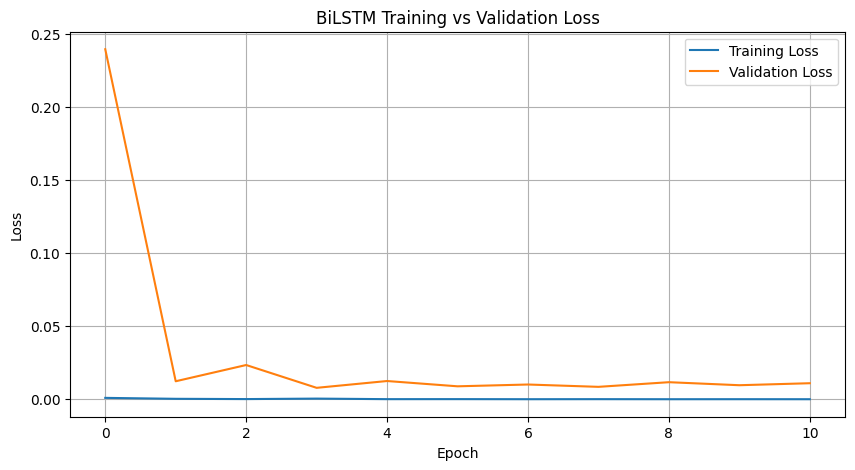

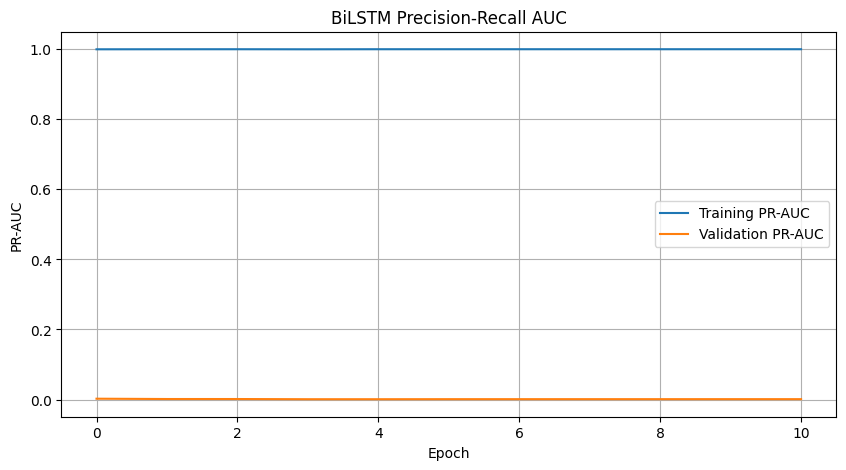

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["pr_auc"], label="Training PR-AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("BiLSTM Precision-Recall AUC")
plt.legend()
plt.grid(True)
plt.show()


## 18. Load best model

In [20]:
model = tf.keras.models.load_model(
    "/content/best_chamoli_bilstm.keras",
    custom_objects={
        "loss": binary_focal_loss(
            gamma=2.0,
            alpha=0.75
        )
    }
)

print("Best model loaded.")


Best model loaded.


## 19. Validation threshold optimization

In [21]:
from sklearn.metrics import precision_recall_curve, f1_score

val_probability = model.predict(
    X_val_seq,
    batch_size=256,
    verbose=1
).ravel()

precision, recall, thresholds = precision_recall_curve(
    y_val_seq,
    val_probability
)

if len(thresholds) == 0:
    raise ValueError(
        "No validation thresholds available. "
        "Check validation labels and predictions."
    )

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (
        precision[:-1]
        +
        recall[:-1]
        +
        1e-8
    )
)

best_index = np.argmax(f1_scores)
BEST_THRESHOLD = float(thresholds[best_index])

print("Best validation threshold:", BEST_THRESHOLD)
print("Validation precision:", precision[best_index])
print("Validation recall:", recall[best_index])
print("Validation F1:", f1_scores[best_index])


138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step
Best validation threshold: 0.9969623684883118
Validation precision: 0.015306122448979591
Validation recall: 0.16666666666666666
Validation F1: 0.028037381636824264


## 20. Final test evaluation

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

test_probability = model.predict(
    X_test_seq,
    batch_size=256,
    verbose=1
).ravel()

test_prediction = (
    test_probability >= BEST_THRESHOLD
).astype(int)

accuracy = accuracy_score(
    y_test_seq,
    test_prediction
)

precision_value = precision_score(
    y_test_seq,
    test_prediction,
    zero_division=0
)

recall_value = recall_score(
    y_test_seq,
    test_prediction,
    zero_division=0
)

f1_value = f1_score(
    y_test_seq,
    test_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_seq,
    test_probability
)

pr_auc = average_precision_score(
    y_test_seq,
    test_probability
)

print("\n" + "=" * 65)
print("          CHAMOLI BiLSTM FINAL RESULTS")
print("=" * 65)
print(f"Threshold : {BEST_THRESHOLD:.4f}")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision_value * 100:.2f}%")
print(f"Recall    : {recall_value * 100:.2f}%")
print(f"F1 Score  : {f1_value * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Actual Flood samples    : {y_test_seq.sum()}")
print(f"Predicted Flood samples : {test_prediction.sum()}")
print("=" * 65)


138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step

          CHAMOLI BiLSTM FINAL RESULTS
Threshold : 0.9970
Accuracy  : 96.45%
Precision : 1.43%
Recall    : 75.00%
F1 Score  : 2.81%
ROC-AUC   : 0.9802
PR-AUC    : 0.0282
Actual Flood samples    : 24
Predicted Flood samples : 1259


## 21. Confusion matrix and TP check

In [23]:
cm = confusion_matrix(
    y_test_seq,
    test_prediction,
    labels=[0, 1]
)

TN, FP, FN, TP = cm.ravel()

print("\n" + "=" * 50)
print("CONFUSION MATRIX VALUES")
print("=" * 50)
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"TP = {TP}")
print("=" * 50)

if TP > 0:
    print("SUCCESS: Flood-Flood quadrant (TP) is non-zero.")
else:
    print(
        "WARNING: TP is still zero. "
        "Do not artificially change the test labels or threshold; "
        "inspect the data/model and report this honestly."
    )



CONFUSION MATRIX VALUES
TN = 33815
FP = 1241
FN = 6
TP = 18
SUCCESS: Flood-Flood quadrant (TP) is non-zero.


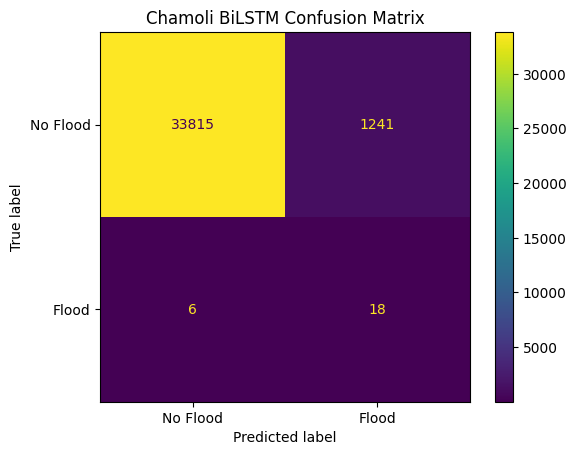

              precision    recall  f1-score   support

    No Flood       1.00      0.96      0.98     35056
       Flood       0.01      0.75      0.03        24

    accuracy                           0.96     35080
   macro avg       0.51      0.86      0.50     35080
weighted avg       1.00      0.96      0.98     35080



In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Flood", "Flood"]
)

disp.plot(values_format="d")
plt.title("Chamoli BiLSTM Confusion Matrix")
plt.show()

print(
    classification_report(
        y_test_seq,
        test_prediction,
        target_names=["No Flood", "Flood"],
        zero_division=0
    )
)


## 22. Save model, scaler and configuration

In [25]:
import joblib

model.save(
    "/content/chamoli_bilstm_final.keras"
)

joblib.dump(
    scaler,
    "/content/chamoli_scaler.pkl"
)

joblib.dump(
    train_medians,
    "/content/chamoli_train_medians.pkl"
)

config = {
    "features": FEATURES,
    "sequence_length": SEQUENCE_LENGTH,
    "target": TARGET,
    "threshold": float(BEST_THRESHOLD)
}

joblib.dump(
    config,
    "/content/chamoli_model_config.pkl"
)

print("Saved:")
print("/content/chamoli_bilstm_final.keras")
print("/content/chamoli_scaler.pkl")
print("/content/chamoli_train_medians.pkl")
print("/content/chamoli_model_config.pkl")


Saved:
/content/chamoli_bilstm_final.keras
/content/chamoli_scaler.pkl
/content/chamoli_train_medians.pkl
/content/chamoli_model_config.pkl


## 23. Date/timestamp prediction function

In [26]:
def predict_timestamp(user_input):

    user_time = pd.to_datetime(
        user_input,
        errors="coerce"
    )

    if pd.isna(user_time):
        print("Invalid date/time.")
        return None

    # Work on a clean copy and preserve original dataframe indices.
    feature_values_df = df[FEATURES].copy()
    feature_values_df = feature_values_df.fillna(train_medians)
    feature_values = scaler.transform(feature_values_df)

    # Exact timestamp
    exact_matches = df.index[
        df["timestamp"] == user_time
    ].tolist()

    if exact_matches:
        idx = exact_matches[0]

        # The current global df is sorted/reset, so positional index = idx.
        if idx < SEQUENCE_LENGTH - 1:
            print("Not enough previous hours for prediction.")
            return None

        sequence = feature_values[
            idx - SEQUENCE_LENGTH + 1:
            idx + 1
        ]

        probability = float(
            model.predict(
                np.expand_dims(sequence, axis=0),
                verbose=0
            )[0][0]
        )

        prediction = (
            "FLOOD"
            if probability >= BEST_THRESHOLD
            else "NO FLOOD"
        )

        print("\n" + "=" * 60)
        print("          AI FLOOD PREDICTION")
        print("=" * 60)
        print(f"Timestamp          : {user_time}")
        print(f"Flood Probability  : {probability * 100:.2f}%")
        print(f"Prediction         : {prediction}")
        print(f"Model Threshold    : {BEST_THRESHOLD * 100:.2f}%")
        print("=" * 60)

        return {
            "timestamp": user_time,
            "flood_probability": probability,
            "prediction": prediction
        }

    # Date-only input
    date_matches = df[
        df["timestamp"].dt.date == user_time.date()
    ]

    if len(date_matches) == 0:
        print("Date not found in dataset.")
        return None

    results = []

    for idx in date_matches.index:
        if idx < SEQUENCE_LENGTH - 1:
            continue

        sequence = feature_values[
            idx - SEQUENCE_LENGTH + 1:
            idx + 1
        ]

        probability = float(
            model.predict(
                np.expand_dims(sequence, axis=0),
                verbose=0
            )[0][0]
        )

        results.append({
            "timestamp": df.loc[idx, "timestamp"],
            "flood_probability": probability
        })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        print("Not enough historical data for this date.")
        return None

    results_df["prediction"] = np.where(
        results_df["flood_probability"] >= BEST_THRESHOLD,
        "FLOOD",
        "NO FLOOD"
    )

    max_row = results_df.loc[
        results_df["flood_probability"].idxmax()
    ]

    print("\n" + "=" * 65)
    print("             AI DAILY FLOOD PREDICTION")
    print("=" * 65)
    print(f"Date                  : {user_time.date()}")
    print(
        f"Maximum Flood Risk    : "
        f"{max_row['flood_probability'] * 100:.2f}%"
    )
    print(
        f"Highest Risk Time     : "
        f"{max_row['timestamp']}"
    )
    print(
        f"Daily Prediction      : "
        f"{max_row['prediction']}"
    )
    print(
        f"Model Threshold       : "
        f"{BEST_THRESHOLD * 100:.2f}%"
    )
    print("=" * 65)

    display_df = results_df.copy()
    display_df["flood_probability"] = (
        display_df["flood_probability"] * 100
    ).round(2)

    display_df.columns = [
        "Timestamp",
        "Flood Probability (%)",
        "Prediction"
    ]

    print("\nHourly predictions:")
    display(display_df)

    return results_df


## 24. User date/timestamp prediction

In [27]:
user_time = input(
    "Enter timestamp/date "
    "(example: 2026-09-09 12:00:00 or 2026-08-01): "
)

prediction_results = predict_timestamp(user_time)


Enter timestamp/date (example: 2026-09-09 12:00:00 or 2026-08-01): 2026-07-05

          AI FLOOD PREDICTION
Timestamp          : 2026-07-05 00:00:00
Flood Probability  : 99.71%
Prediction         : FLOOD
Model Threshold    : 99.70%


## 25. Optional: download trained files

In [28]:
from google.colab import files

print("Use these one at a time if you want to download them:")
print("/content/chamoli_bilstm_final.keras")
print("/content/chamoli_scaler.pkl")
print("/content/chamoli_train_medians.pkl")
print("/content/chamoli_model_config.pkl")

# Uncomment ONE line at a time:
# files.download("/content/chamoli_bilstm_final.keras")
# files.download("/content/chamoli_scaler.pkl")
# files.download("/content/chamoli_train_medians.pkl")
# files.download("/content/chamoli_model_config.pkl")


Use these one at a time if you want to download them:
/content/chamoli_bilstm_final.keras
/content/chamoli_scaler.pkl
/content/chamoli_train_medians.pkl
/content/chamoli_model_config.pkl
